# CPU vs GPU Computational Time to Solve 2D Poisson Equation by FEM

## A. Without Sparsing the Densed-Stiffness Matrix:

CPU sparse computation time: 100.77 seconds
L2 Relative Error: 1.3160e-05


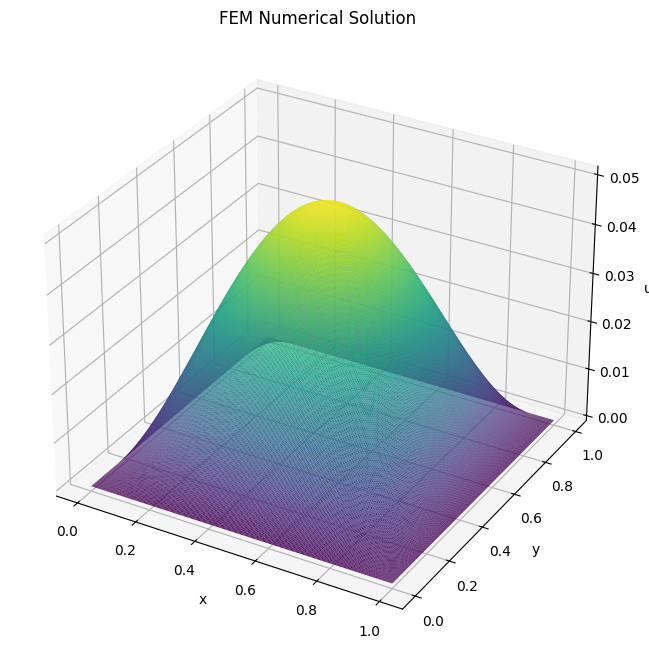

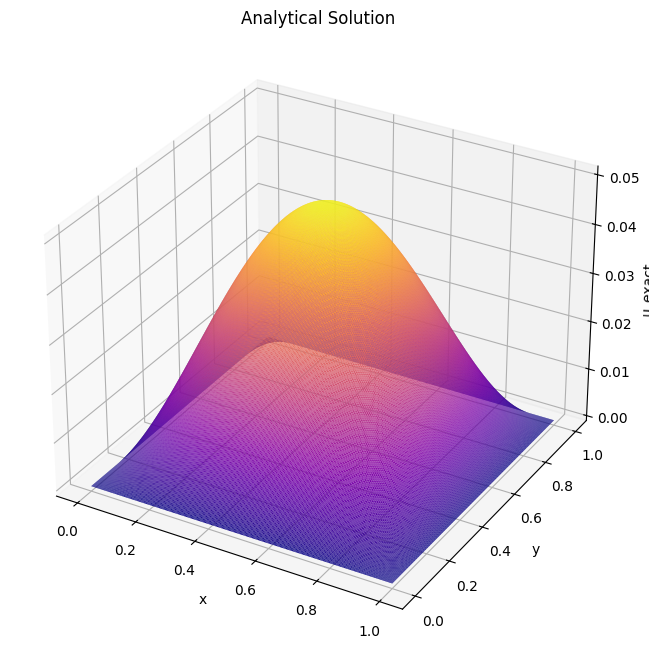

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from mpl_toolkits.mplot3d import Axes3D
import time

start_time = time.time()

# 1. Mesh Generation:
num_grids = 250
x = np.linspace(0, 1, num_grids + 1)
y = np.linspace(0, 1, num_grids + 1)
X, Y = np.meshgrid(x, y)
points = np.vstack([X.ravel(), Y.ravel()]).T
point_indices = np.arange((num_grids + 1)**2).reshape((num_grids + 1, num_grids + 1))

triangles = []
for i in range(num_grids):
    for j in range(num_grids):
        bl = point_indices[j, i]
        br = point_indices[j, i + 1]
        tr = point_indices[j + 1, i + 1]
        tl = point_indices[j + 1, i]
        triangles.append([bl, br, tr])
        triangles.append([bl, tr, tl])
triangles = np.array(triangles)

# 2. Basis Functions:
def basis_functions(coords):
    A = np.ones((3, 3))
    A[:, 0:2] = coords
    grads = np.zeros((3, 2))
    for k in range(3):
        rhs = np.zeros(3)
        rhs[k] = 1
        sol = np.linalg.solve(A, rhs)
        grads[k, :] = sol[0:2]
    area = 0.5 * abs(np.linalg.det(A))
    return grads, area

# 3. Source term and analytical solution
def source_term(x, y):
    return np.sin(np.pi * x) * np.sin(np.pi * y)

def analytical_solution(x, y):
    return (1 / (2 * np.pi**2)) * np.sin(np.pi * x) * np.sin(np.pi * y)

# 4. Assembly of global matrices
K = np.zeros((points.shape[0], points.shape[0]))
F = np.zeros(points.shape[0])

for t in triangles:
    coords = points[t]
    grads, area = basis_functions(coords)
    kt = grads @ grads.T * area

    f_values = source_term(coords[:, 0], coords[:, 1])
    ft = f_values * (area / 3)  

    for i in range(3):
        global_i = t[i]
        F[global_i] += ft[i]
        for j in range(3):
            global_j = t[j]
            K[global_i, global_j] += kt[i, j]


# 5. Boundary Condition (u = 0 on boundary)
boundary_nodes = np.where(
    (np.isclose(points[:, 0], 0)) |
    (np.isclose(points[:, 0], 1)) |
    (np.isclose(points[:, 1], 0)) |
    (np.isclose(points[:, 1], 1))
)[0]


for node in boundary_nodes:
    K[node, :] = 0
    K[node, node] = 1
    F[node] = 0


# 6. Solve the system
u = np.linalg.solve(K, F)

end_time = time.time()
print(f"CPU sparse computation time: {end_time - start_time:.2f} seconds")

# 7. Analytical solution and error
u_exact = analytical_solution(points[:, 0], points[:, 1])
error_l2 = np.linalg.norm(u - u_exact) / np.linalg.norm(u_exact)
print(f"L2 Relative Error: {error_l2:.4e}")


# 8. Numerical Solution
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_trisurf(points[:, 0], points[:, 1], triangles, u, cmap='viridis', edgecolor='none')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('u')
ax.set_title('FEM Numerical Solution')
plt.show()


# 9. Analytical Solution
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_trisurf(points[:, 0], points[:, 1], triangles, u_exact, cmap='plasma', edgecolor='none')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('u_exact')
ax.set_title('Analytical Solution')
plt.show()



In [5]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from mpl_toolkits.mplot3d import Axes3D
import time

start_gpu = time.time()

# 1. Mesh Generation
num_grids = 250
x = np.linspace(0, 1, num_grids + 1)
y = np.linspace(0, 1, num_grids + 1)
X, Y = np.meshgrid(x, y)
points = np.vstack([X.ravel(), Y.ravel()]).T
point_indices = np.arange((num_grids + 1)**2).reshape((num_grids + 1, num_grids + 1))

triangles = []
for i in range(num_grids):
    for j in range(num_grids):
        bl = point_indices[j, i]
        br = point_indices[j, i + 1]
        tr = point_indices[j + 1, i + 1]
        tl = point_indices[j + 1, i]
        triangles.append([bl, br, tr])
        triangles.append([bl, tr, tl])
triangles = np.array(triangles)

# 2. Basis Functions
def basis_functions(coords):
    A = np.ones((3, 3))
    A[:, 0:2] = coords
    grads = np.zeros((3, 2))
    for k in range(3):
        rhs = np.zeros(3)
        rhs[k] = 1
        sol = np.linalg.solve(A, rhs)
        grads[k, :] = sol[0:2]
    area = 0.5 * abs(np.linalg.det(A))
    return grads, area

# 3. Source term and analytical solution
def source_term(x, y):
    return np.sin(np.pi * x) * np.sin(np.pi * y)

def analytical_solution(x, y):
    return (1 / (2 * np.pi**2)) * np.sin(np.pi * x) * np.sin(np.pi * y)

# 4. Assembly of global matrices
n_points = points.shape[0]
K = np.zeros((n_points, n_points))
F = np.zeros(n_points)

for t in triangles:
    coords = points[t]
    grads, area = basis_functions(coords)
    kt = grads @ grads.T * area

    f_values = source_term(coords[:, 0], coords[:, 1]) 
    ft = f_values * (area / 3)  

    for i in range(3):
        global_i = t[i]
        F[global_i] += ft[i]
        for j in range(3):
            global_j = t[j]
            K[global_i, global_j] += kt[i, j]

# 5. Boundary Condition (u = 0 on boundary)
boundary_nodes = np.where(
    (np.isclose(points[:, 0], 0)) |
    (np.isclose(points[:, 0], 1)) |
    (np.isclose(points[:, 1], 0)) |
    (np.isclose(points[:, 1], 1))
)[0]

for node in boundary_nodes:
    K[node, :] = 0
    K[node, node] = 1
    F[node] = 0


# 6. Solve the system
K_gpu = cp.asarray(K)
F_gpu = cp.asarray(F)
u_gpu = cp.linalg.solve(K_gpu, F_gpu)

end_gpu = time.time()
print(f"GPU solve time: {end_gpu - start_gpu:.2f} s")

# 7. Analytical and Error
u_gpu_cpu = cp.asnumpy(u_gpu)
u_exact = analytical_solution(points[:, 0], points[:, 1])
error_l2 = np.linalg.norm(u_gpu_cpu - u_exact) / np.linalg.norm(u_exact)
print(f"L2 Relative Error (GPU solution): {error_l2:.4e}")

# 8. Plotting
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_trisurf(points[:, 0], points[:, 1], triangles, u_gpu_cpu, cmap='viridis', edgecolor='none')
ax.set_title('FEM Solution (GPU solve)')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('u')
plt.show()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_trisurf(points[:, 0], points[:, 1], triangles, u_exact, cmap='plasma', edgecolor='none')
ax.set_title('Analytical Solution')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('u_exact')
plt.show()


OutOfMemoryError: Out of memory allocating 31,753,008,128 bytes (allocated so far: 0 bytes).

## B. Sparsing the Densed-Stiffness Matrix:

CPU sparse computation time: 20.27 seconds
L2 Relative Error: 1.3160e-05


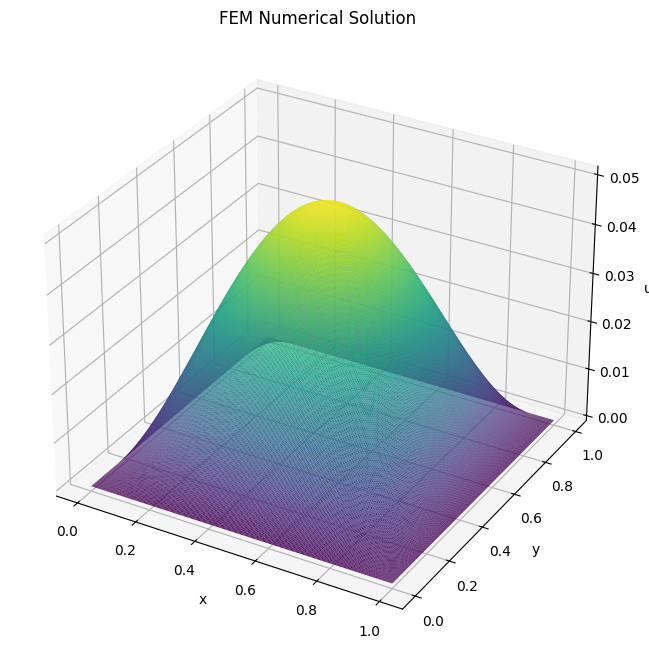

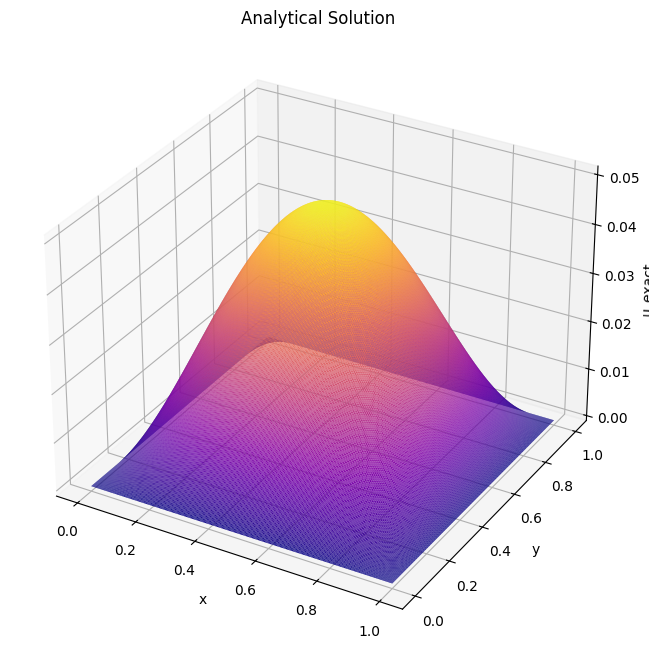

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from mpl_toolkits.mplot3d import Axes3D
import time
from scipy.sparse.linalg import spsolve
from scipy.sparse import csr_matrix
import scipy

start_time = time.time()


# 1. Mesh Generation:
num_grids = 250
x = np.linspace(0, 1, num_grids + 1)
y = np.linspace(0, 1, num_grids + 1)
X, Y = np.meshgrid(x, y)
points = np.vstack([X.ravel(), Y.ravel()]).T
point_indices = np.arange((num_grids + 1)**2).reshape((num_grids + 1, num_grids + 1))

triangles = []
for i in range(num_grids):
    for j in range(num_grids):
        bl = point_indices[j, i]
        br = point_indices[j, i + 1]
        tr = point_indices[j + 1, i + 1]
        tl = point_indices[j + 1, i]
        triangles.append([bl, br, tr])
        triangles.append([bl, tr, tl])

triangles = np.array(triangles)

# 2. Basis Functions:
def basis_functions(coords):
    A = np.ones((3, 3))
    A[:, 0:2] = coords
    grads = np.zeros((3, 2))
    for k in range(3):
        rhs = np.zeros(3)
        rhs[k] = 1
        sol = np.linalg.solve(A, rhs)
        grads[k, :] = sol[0:2]
    area = 0.5 * abs(np.linalg.det(A))
    return grads, area

# 3. Source term and analytical solution
def source_term(x, y):
    return np.sin(np.pi * x) * np.sin(np.pi * y)

def analytical_solution(x, y):
    return (1 / (2 * np.pi**2)) * np.sin(np.pi * x) * np.sin(np.pi * y)

# 4. Assembly of global matrices
K = np.zeros((points.shape[0], points.shape[0]))
F = np.zeros(points.shape[0])

for t in triangles:
    coords = points[t]
    grads, area = basis_functions(coords)
    kt = grads @ grads.T * area

    f_values = source_term(coords[:, 0], coords[:, 1])
    ft = f_values * (area / 3)  

    for i in range(3):
        global_i = t[i]
        F[global_i] += ft[i]
        for j in range(3):
            global_j = t[j]
            K[global_i, global_j] += kt[i, j]


# 5. Boundary Condition (u = 0 on boundary)
boundary_nodes = np.where(
    (np.isclose(points[:, 0], 0)) |
    (np.isclose(points[:, 0], 1)) |
    (np.isclose(points[:, 1], 0)) |
    (np.isclose(points[:, 1], 1))
)[0]


for node in boundary_nodes:
    K[node, :] = 0
    K[node, node] = 1
    F[node] = 0

K_sparse = csr_matrix(K)             
F = F.astype(float).reshape(-1) 


u = spsolve(K_sparse, F)  

end_time1 = time.time()

print(f"CPU sparse computation time: {end_time1 - start_time:.2f} seconds")


# 7. Analytical solution and error
u_exact = analytical_solution(points[:, 0], points[:, 1])
error_l2 = np.linalg.norm(u - u_exact) / np.linalg.norm(u_exact)
print(f"L2 Relative Error: {error_l2:.4e}")


# 8. Numerical Solution
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_trisurf(points[:, 0], points[:, 1], triangles, u, cmap='viridis', edgecolor='none')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('u')
ax.set_title('FEM Numerical Solution')
plt.show()


# 9. Analytical Solution
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_trisurf(points[:, 0], points[:, 1], triangles, u_exact, cmap='plasma', edgecolor='none')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('u_exact')
ax.set_title('Analytical Solution')
plt.show()



GPU solve time: 21.98 s
L2 Relative Error (GPU solution): 1.3160e-05


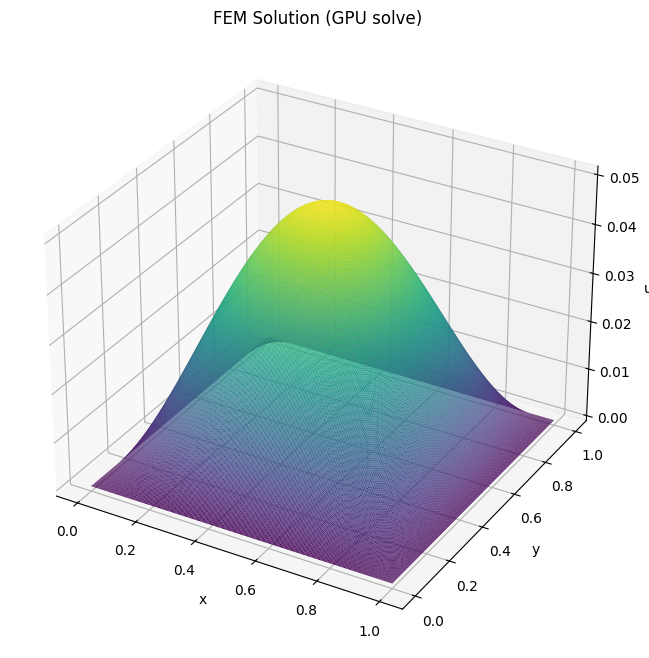

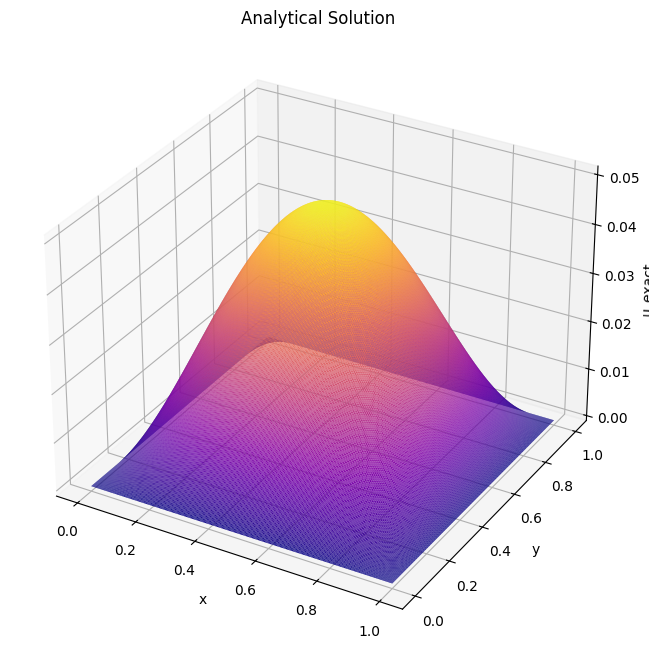

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from mpl_toolkits.mplot3d import Axes3D
import time
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import spsolve as cpu_spsolve

import cupy as cp
from cupyx.scipy.sparse import csr_matrix as gpu_csr_matrix
from cupyx.scipy.sparse.linalg import spsolve as gpu_spsolve

start_gpu = time.time()

# 1. Mesh Generation
num_grids = 250
x = np.linspace(0, 1, num_grids + 1)
y = np.linspace(0, 1, num_grids + 1)
X, Y = np.meshgrid(x, y)
points = np.vstack([X.ravel(), Y.ravel()]).T
point_indices = np.arange((num_grids + 1)**2).reshape((num_grids + 1, num_grids + 1))

triangles = []
for i in range(num_grids):
    for j in range(num_grids):
        bl = point_indices[j, i]
        br = point_indices[j, i + 1]
        tr = point_indices[j + 1, i + 1]
        tl = point_indices[j + 1, i]
        triangles.append([bl, br, tr])
        triangles.append([bl, tr, tl])
triangles = np.array(triangles)

# 2. Basis Functions
def basis_functions(coords):
    A = np.ones((3, 3))
    A[:, 0:2] = coords
    grads = np.zeros((3, 2))
    for k in range(3):
        rhs = np.zeros(3)
        rhs[k] = 1
        sol = np.linalg.solve(A, rhs)
        grads[k, :] = sol[0:2]
    area = 0.5 * abs(np.linalg.det(A))
    return grads, area

# 3. Source term and analytical solution
def source_term(x, y):
    return np.sin(np.pi * x) * np.sin(np.pi * y)

def analytical_solution(x, y):
    return (1 / (2 * np.pi**2)) * np.sin(np.pi * x) * np.sin(np.pi * y)

# 4. Assembly of global matrices
n_points = points.shape[0]
K = np.zeros((n_points, n_points))
F = np.zeros(n_points)

for t in triangles:
    coords = points[t]
    grads, area = basis_functions(coords)
    kt = grads @ grads.T * area

    f_values = source_term(coords[:, 0], coords[:, 1]) 
    ft = f_values * (area / 3)  

    for i in range(3):
        global_i = t[i]
        F[global_i] += ft[i]
        for j in range(3):
            global_j = t[j]
            K[global_i, global_j] += kt[i, j]

# 5. Boundary Condition (u = 0 on boundary)
boundary_nodes = np.where(
    (np.isclose(points[:, 0], 0)) |
    (np.isclose(points[:, 0], 1)) |
    (np.isclose(points[:, 1], 0)) |
    (np.isclose(points[:, 1], 1))
)[0]

for node in boundary_nodes:
    K[node, :] = 0
    K[node, node] = 1
    F[node] = 0

# 6. Sparse conversion
K_csr = csr_matrix(K)

# 7. GPU Solve
K_gpu = gpu_csr_matrix(K_csr)
F_gpu = cp.asarray(F)

u_gpu = gpu_spsolve(K_gpu, F_gpu)

end_gpu = time.time()
print(f"GPU solve time: {end_gpu - start_gpu:.2f} s")

# 8. Analytical and Error
u_gpu_cpu = cp.asnumpy(u_gpu)
u_exact = analytical_solution(points[:, 0], points[:, 1])
error_l2 = np.linalg.norm(u_gpu_cpu - u_exact) / np.linalg.norm(u_exact)
print(f"L2 Relative Error (GPU solution): {error_l2:.4e}")

# 9. Plotting
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_trisurf(points[:, 0], points[:, 1], triangles, u_gpu_cpu, cmap='viridis', edgecolor='none')
ax.set_title('FEM Solution (GPU solve)')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('u')
plt.show()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_trisurf(points[:, 0], points[:, 1], triangles, u_exact, cmap='plasma', edgecolor='none')
ax.set_title('Analytical Solution')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('u_exact')
plt.show()
